# Predict Air Quality: Calling MATLAB from Python Using MATLAB Engine API

Import the weather data and use the MATLAB code to predict air quality.

This example uses the MATLAB Engine API, which runs a MATLAB session. More info and set up instructions are included here: https://www.mathworks.com/help/matlab/matlab-engine-for-python.html

In order to connect to MATLAB with Python, you have to install the MATLAB Engine API for Python:

Search for the *matlabroot* where MATLAB is installed, and execute the install function from the setup.py python library.
On Windows, it would look like this:

```
cd "C:\Program Files\MATLAB\R2021a\extern\engines\python"
python setup.py install
```


In [1]:
f = open("accessKey.txt", "r")
for r in f:
    apikey = f.readline()
f.close()

## Read the current weather data

In [2]:
import weather

In [3]:
json_data = weather.get_current_weather("Boston","US",apikey)
data = weather.parse_current_json(json_data)
print(data)

{'temp': 71.11, 'feels_like': 72.3, 'temp_min': 68.88, 'temp_max': 73.09, 'pressure': 1009, 'humidity': 93, 'speed': 4, 'deg': 316, 'gust': 15.01, 'lon': -71.0598, 'lat': 42.3584, 'city': 'Boston', 'current_time': '2021-07-01 11:20:37.435410'}


## Start MATLAB through the MATLAB Engine API.

In [4]:
import matlab.engine

In [5]:
m = matlab.engine.start_matlab()

Test a simple function

In [6]:
# x = m.sqrt(42) # error
x = m.sqrt(float(42))
print(x)

6.48074069840786


Print the MATLAB working directory

In [7]:
m.pwd()

'C:\\Users\\ydebray\\MATLAB Drive\\pythonwithmatlab\\PythonWeatherPrediction\\2_CallMATLABfromPython'

Specify number of output arguments 

In [8]:
x = m.gcd(10,5,nargout=2)
print(x)

(5, 0)


In [9]:
x[0]

5

Play around (easter eggs)

In [10]:
m.spy(nargout=0)

In [11]:
m.life(nargout=0)

Retrieve plot from MATLAB/Python data

In [12]:
a = float(0)
b = float(10)
x = m.linspace(a,b)
y = m.sin(x)

In [17]:
import math
x = list(range(10))
y = [math.sin(i) for i in x]
# Data conversion
x = matlab.double(x)
y = matlab.double(y)

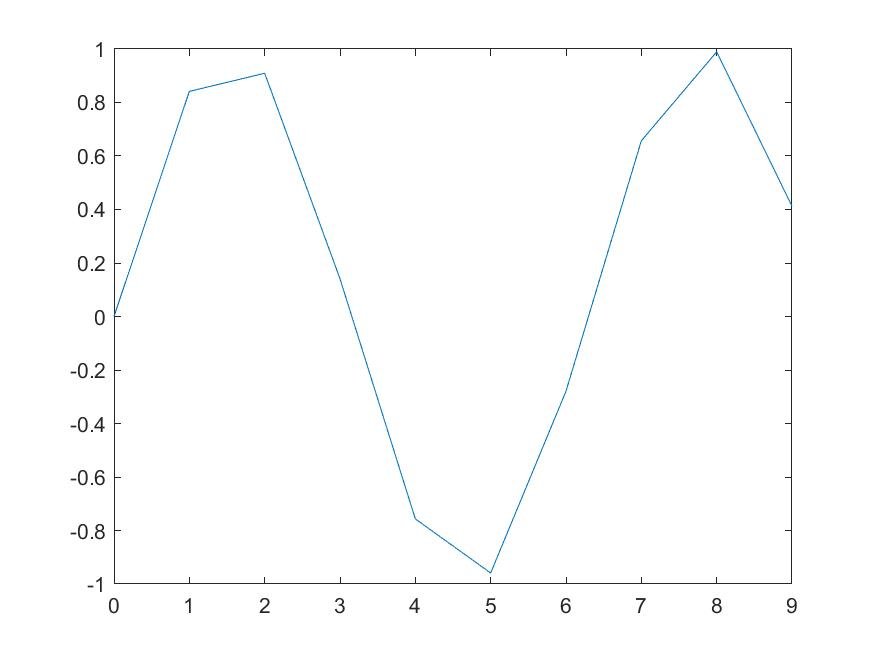

In [18]:
from IPython.display import Image
plotName = 'myPlot'
m.plot_print(x,y,plotName, nargout=0)
Image(filename = plotName+".jpg")

## Call ML apps

In [19]:
import numpy as np
X = np.random.rand(1000,2)
y = np.dot(X, np.array([3,2])) + 0.5 # 3*x1 + 2*x2 + 1/2

In [20]:
# Convert Numpy array to list to MATLAB Double
X_ml = matlab.double(X.tolist())
y_ml = matlab.double(y.tolist())
y_ml.reshape((y.size,1))

In [21]:
m.regressionLearner(X_ml, y_ml, nargout=0)

In [22]:
res = m.trainRegressionModel(X_ml, y_ml, nargout=2)

In [23]:
# Outputs a Python dict - struct back in MATLAB
import pprint as pp
pp.pprint(res[0])

{'About': 'This struct is a trained model exported from Regression Learner '
          'R2021a.',
 'HowToPredict': 'To make predictions on a new predictor column matrix, X, '
                 'use: \n'
                 '  yfit = c.predictFcn(X) \n'
                 "replacing 'c' with the name of the variable that is this "
                 "struct, e.g. 'trainedModel'. \n"
                 ' \n'
                 'X must contain exactly 2 columns because this model was '
                 'trained using 2 predictors. \n'
                 'X must contain only predictor columns in exactly the same '
                 'order and format as your training \n'
                 'data. Do not include the response column or any columns you '
                 'did not import into the app. \n'
                 ' \n'
                 'For more information, see <a '
                 'href="matlab:helpview(fullfile(docroot, \'stats\', '
                 "'stats.map'), "
                 '\'appregressio

In [24]:
predFcn = res[0].get('predictFcn')

In [25]:
# Test the model
X_test = np.array([-1,2])
X_test = matlab.double(X_test.tolist())
y_test = m.feval(predFcn, X_test)  # 3*x1 + 2*x2 + 1/2
y_test 

1.5000000000000027

In [26]:
m.exit()

## Predict air quality

connect to an existing MATLAB session:
* `matlab.engine.shareEngine`
* `matlab.engine.engineName`

In [27]:
m = matlab.engine.connect_matlab('MATLAB_19984')

In [28]:
m.evalc("x=0", nargout = 0)

In [29]:
m.workspace['x']

0.0

place a breakpoint in `predictAirQual.m` for visual debugging

In [30]:
aq = m.predictAirQual(data)
print(aq)

Moderate


## Exit the MATLAB engine

In [31]:
m.exit()

Copyright 2019 - 2021 The MathWorks, Inc.